<a href="https://colab.research.google.com/github/hsmu-jeongeun/machine-learning-practice/blob/main/250528__solubility_prediction_model_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# DeepChem 설치

Colab 노트북에 DeepChem 설치

tensorflow 기반 모델을 사용할 것이므로 pip install 명령에 [tensorflow]를 추가하여 필요한 종속성도 설치

In [2]:
# DeepChem 설치시 Keras 종속성 버전 일치를 위해 아래 환경 변수 설정 후 import 진행
import os
os.environ["TF_USE_LEGACY_KERAS"] = '1'

In [3]:
!pip install deepchem[tensorflow]

zsh:1: no matches found: deepchem[tensorflow]


## 기타 모듈 설치
- rdkit 설치
- 레거시 옵티마이저 사용을 위한 tf_keras 설치(deepchem ver 2.4.0일 때만)

In [4]:
!pip install rdkit

In [5]:
!pip install tf_keras

## deepchem 버전 확인

In [6]:
import deepchem as dc
dc.__version__

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/opt/anaconda3/envs/py311/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/opt/anaconda3/envs/py311/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


'2.8.0'

## warning 메시지 생략

In [7]:
import warnings
warnings.filterwarnings(action='ignore')

# 분자 데이터 피처화

In [8]:
from rdkit import Chem

# SMILES와 확장 연결 지문(ECFP)
smiles_example = ['C1CCCCC1C', 'O1CCOCC1']
mols = [Chem.MolFromSmiles(s) for s in smiles_example] # rdkit 라이브러리를 사용하여 SMILES 문자열을 분자 객체로 변환
feat = dc.feat.CircularFingerprint(size=1024)
arr = feat.featurize(mols)
arr.shape

[10:50:23] DEPRECATION WARNING: please use MorganGenerator
[10:50:23] DEPRECATION WARNING: please use MorganGenerator


(2, 1024)

In [9]:
# 분자 표현자
feat = dc.feat.RDKitDescriptors()
arr = feat.featurize(mols)
arr.shape

(2, 217)

# 용해도 예측 모델 만들기
DeepChem 라이브러리를 사용하여 그래프 합성곱 신경망을 학습시켜 분자의 용해도를 예측하는 실습 진행

Delaney 데이터 : 분자의 SMILES 표현과 해당 분자의 용해도 값을 포함함

## 데이터 불러오기 및 확인

In [15]:
!curl -o delaney-processed.csv https://raw.githubusercontent.com/deepchem/deepchem/master/datasets/delaney-processed.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 96699  100 96699    0     0  2097k      0 --:--:-- --:--:-- --:--:-- 2146k


In [16]:
import pandas as pd
dataset = pd.read_csv("delaney-processed.csv")
print(dataset.shape)
dataset.head()

(1128, 10)


,Compound ID,ESOL predicted log solubility in mols per litre,Minimum Degree,Molecular Weight,Number of H-Bond Donors,Number of Rings,Number of Rotatable Bonds,Polar Surface Area,measured log solubility in mols per litre,smiles
0,Amigdalin,-0.974,1,457.432,7,3,7,202.32,-0.77,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...
1,Fenfuram,-2.885,1,201.225,1,2,2,42.24,-3.30,Cc1occc1C(=O)Nc2ccccc2
2,citral,-2.579,1,152.237,0,0,4,17.07,-2.06,CC(C)=CCCC(C)=CC(=O)
3,Picene,-6.618,2,278.354,0,5,0,0.00,-7.87,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43
4,Thiophene,-2.232,2,84.143,0,1,0,0.00,-1.33,c1ccsc1


In [17]:
import deepchem as dc

tasks, datasets, transformers = dc.molnet.load_delaney(featurizer='GraphConv')
train_dataset, valid_dataset, test_dataset = datasets

In [18]:
tasks

['measured log solubility in mols per litre']

In [19]:
transformers

In [20]:
train_dataset.X[0]

In [21]:
# ConvMol 특성의 구조 (원자가 11이고, 특성 벡터수가 75)
train_dataset.X[0].atom_features.shape

(11, 75)

In [22]:
train_dataset.X[0].get_atom_features()

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0.

In [23]:
# 11개 원자의 인접 노드 번호들 보기
train_dataset.X[0].get_adjacency_list()

[[9],
 [10],
 [4],
 [9],
 [6, 2],
 [7, 10],
 [10, 4],
 [8, 5],
 [9, 7],
 [0, 3, 8],
 [5, 1, 6]]

## 모델 생성 및 훈련

In [24]:
# 모델 생성 및 훈련
model = dc.models.GraphConvModel(n_tasks=1, mode='regression', dropout=0.2, batch_normalize=False) # n_tasks : 출력층 지정
model.fit(train_dataset, nb_epoch=100)

0.06501240730285644

확인문제 1 : regression 모드와 classification 모드 중 regression 모드 사용 이유를 적어보세요

-> Delaney 데이터셋은 수용성에 대한 실험적 측정값을 포함하는 회귀 문제이므로, 모델이 연속적인 값을 예측할 수 있도록 regression 모드를 사용함. Classification 모드는 범주형 레이블을 예측하는 데 사용되며, 이 경우에는 적합하지 않음

## 모델 평가

In [25]:
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score) # 피어슨 상관계수 평가지표 사용
print("Training set score")
print(model.evaluate(train_dataset, [metric], transformers))
print("Test set score")
print(model.evaluate(test_dataset, [metric], transformers))

Training set score
{'pearson_r2_score': np.float64(0.9417579475207776)}
Test set score
{'pearson_r2_score': np.float64(0.7167421284082417)}


확인문제 2 : 평가 결과에 대해 셜명하세요

-> 피어슨 상관계수는 모델이 예측한 값과 실제 값 사이의 선형 상관 관계를 측정하는 지표. R2 점수는 1에 가까울수록 모델이 데이터를 잘 설명한다는 것을 의미함. 훈련 세트에서 높은 R2 점수는 모델이 훈련 데이터에 잘 맞춰졌음을 나타내며, 테스트 세트에서의 R2 점수는 모델의 일반화 성능을 평가하는 데 사용됨

## 용해도 예측

In [26]:
smiles = ['COC(C)(C)CCCC(C)CC=CC(C)=CC(=O)OC(C)C',
          'CCOC(=O)CC',
          'CSc1nc(NC(C)C)nc(NC(C)C)n1',
          'CC(C#C)N(C)C(=O)Nc1ccc(Cl)cc1',
          'Cc1cc2ccccc2cc1C']

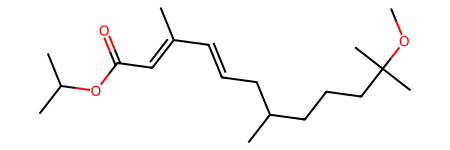

In [27]:
Chem.MolFromSmiles(smiles[0])

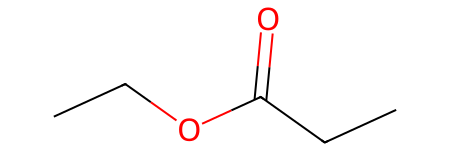

In [28]:
Chem.MolFromSmiles(smiles[1])

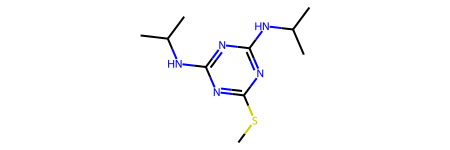

In [29]:
Chem.MolFromSmiles(smiles[2])

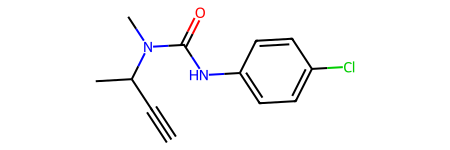

In [30]:
Chem.MolFromSmiles(smiles[3])

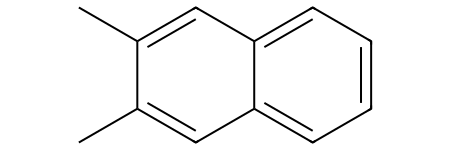

In [31]:
Chem.MolFromSmiles(smiles[4])

In [32]:
mols = [Chem.MolFromSmiles(s) for s in smiles] # SMILES 문자열 -> 분자 객체로 변환
featurizer = dc.feat.ConvMolFeaturizer() # 분자를 Graph 구조로 변환하는 featurizer 정의
x = featurizer.featurize(mols) # Node와 Edge로 이루어진 Graph 구조로 변환
predicted_solubility = model.predict_on_batch(x)

[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[10:52:54] DEPRECATIO

In [33]:
for m,s in zip(smiles, predicted_solubility):
    print()
    print('Molecule:', m)
    print('Predicted solubility:', s)


Molecule: COC(C)(C)CCCC(C)CC=CC(C)=CC(=O)OC(C)C
Predicted solubility: [-0.63335425]

Molecule: CCOC(=O)CC
Predicted solubility: [1.4397776]

Molecule: CSc1nc(NC(C)C)nc(NC(C)C)n1
Predicted solubility: [-0.05602498]

Molecule: CC(C#C)N(C)C(=O)Nc1ccc(Cl)cc1
Predicted solubility: [-0.00295083]

Molecule: Cc1cc2ccccc2cc1C
Predicted solubility: [-0.04518274]


# SMART 문자열
- 분자 내 원자들의 특정 패턴 찾기

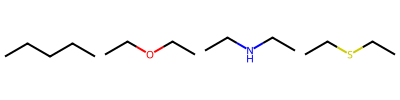

In [34]:
from rdkit.Chem.Draw import MolsToGridImage
smiles_for_smart = ["CCCCC", "CCOCC", "CCNCC", "CCSCC"]
mols_for_smart = [Chem.MolFromSmiles(s) for s in smiles_for_smart]
MolsToGridImage(mols_for_smart, molsPerRow=4, subImgSize=(100, 100))

In [35]:
query = Chem.MolFromSmarts("CCC")
match_list = [mole.GetSubstructMatch(query) for mole in mols_for_smart]
match_list

[(0, 1, 2), (), (), ()]

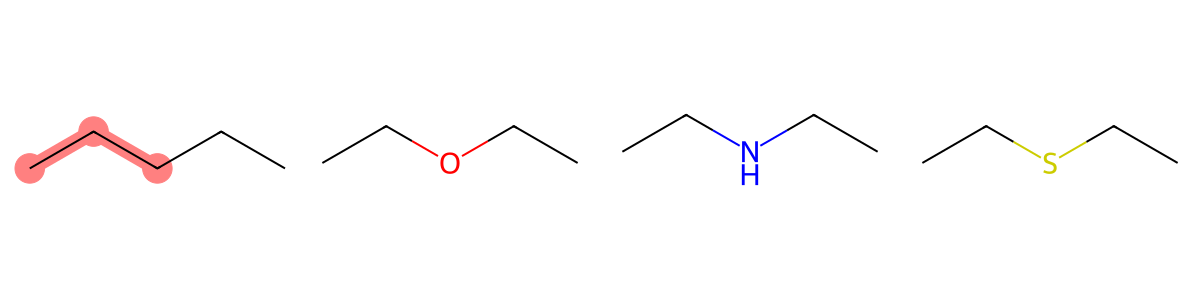

In [36]:
MolsToGridImage(mols_for_smart, molsPerRow=4, subImgSize=(300, 300), highlightAtomLists=match_list)

In [37]:
query = Chem.MolFromSmarts("C[C,O,S]C") # 2개의 탄소 원자 사이에 탄소 or 산소 or 질소 원자 하나가 결합해 있음
match_list = [mole.GetSubstructMatch(query) for mole in mols_for_smart]
match_list

[(0, 1, 2), (1, 2, 3), (), (1, 2, 3)]

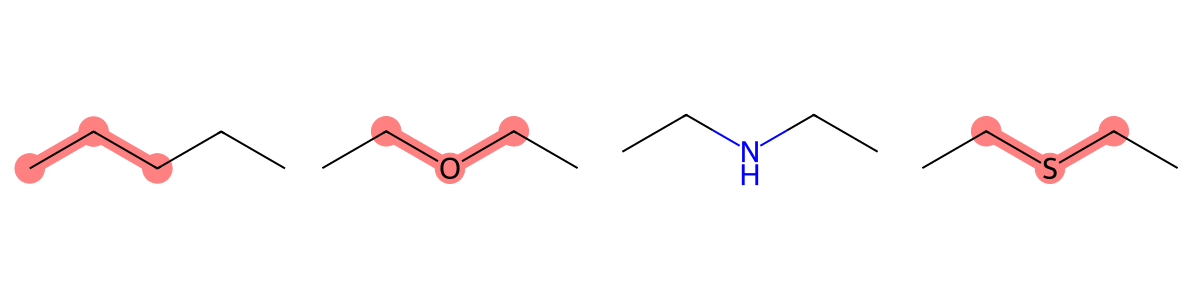

In [38]:
MolsToGridImage(mols_for_smart, molsPerRow=4, subImgSize=(300, 300), highlightAtomLists=match_list)

### 확인 문제 3
- wildcard (*)를 사용해서 "?"에 들어갈 문자열을 작성하세요

In [41]:
wildcard_text = "*"
query = Chem.MolFromSmarts(wildcard_text)

match_list = [mole.GetSubstructMatch(query) for mole in mols_for_smart]
match_list

[(0,), (0,), (0,), (0,)]

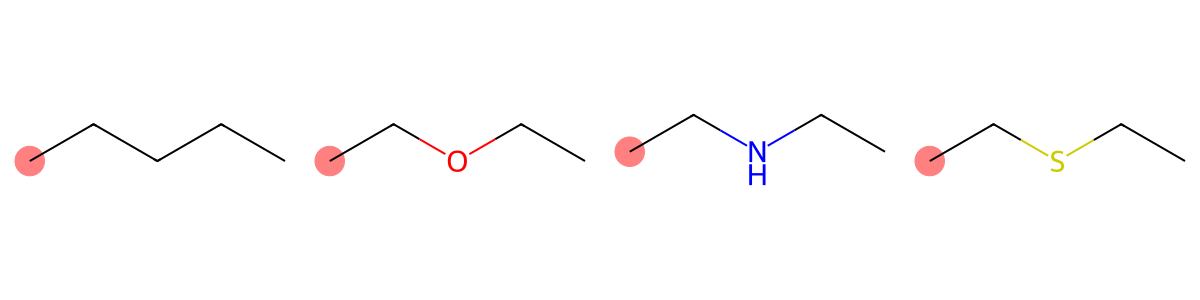

In [42]:
MolsToGridImage(mols_for_smart, molsPerRow=4, subImgSize=(300, 300), highlightAtomLists=match_list)